# Imports

In [1]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-07-04 00:00:03.137169: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-04 00:00:03.336691: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-07-04 00:00:04.346774: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Parameters

In [2]:
exp_id = 0
exp_name = "MNIST"
batch_size = 256
data_path = os.getcwd() + "/data/MNIST"
train_correlation, test_correlation = 0.7, 0.1
epochs = 50
layer_depth = 4
number_of_concepts = 40
patch_size = 8
concept_dataset_size = 2000

# Loading the model and dataset

In [3]:
current_path = os.getcwd()
train_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=train_correlation, train=True)
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=test_correlation, train=False)

for X, y, _ in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
model

Shape of X [N, C, H, W]: torch.Size([256, 3, 28, 28])
Shape of y: torch.Size([256]) torch.int64
Using cuda device


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (l3): Sequential(
    (0): Linear(in_features=512, out_features=10, bias=True)
  )
)

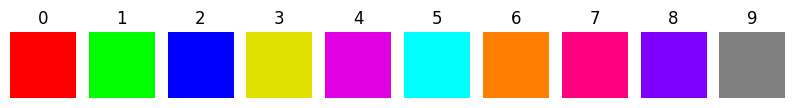

In [4]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

# Training the model

In [5]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y, _) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch *batch_size)% 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y, _ in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

assert(os.path.exists(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}"))
model.load_state_dict(torch.load(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}", weights_only=True))

test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 77.3%, Avg loss: 0.686172 



# Loading craft

In [6]:
g = nn.Sequential(*(list(model.children())[:layer_depth-1]))
h = nn.Sequential(*(list(model.children())[layer_depth-1:]))

craft = Craft(
    input_to_latent=g,
    latent_to_logit = h,
    number_of_concepts = number_of_concepts,
    patch_size = patch_size,
    batch_size = batch_size,
    device = device
)
g, h

(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Sequential(
     (0): Linear(in_features=2352, out_features=512, bias=True)
     (1): ReLU()
   )
   (2): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): ReLU()
   )
 ),
 Sequential(
   (0): Sequential(
     (0): Linear(in_features=512, out_features=10, bias=True)
   )
 ))

# Learning the concepts using the training dataset

In [7]:
concept_dataset = torch.Tensor([])
# for i, (_, label, _) in enumerate(train_data):
#     if label == 3:
#         dataset_3.append(i)
for X, y, y_pred in train_dataloader:
    if len(concept_dataset) >=concept_dataset_size:
        break
    concept_dataset = torch.cat((concept_dataset, X))

# ds3 = rd.sample(dataset_3, concept_dataset_size)
# ds3_im = torch.stack([train_data[i][0] for i in ds3], 0)
crops, crops_u, w = craft.fit(concept_dataset)

crops = np.moveaxis(torch_to_numpy(crops), 1, -1)

crops.shape, crops_u.shape, w.shape

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])
/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


((32768, 8, 8, 3), (32768, 40), (40, 512))

# Estimating the used concept of a specific class

In [8]:
class_label = 9
class_dataset_size = 300

## With testing dataset

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


Concept 5  has an importance value of  0.6164238
Concept 22  has an importance value of  0.12397354
Concept 2  has an importance value of  0.06247443
Concept 28  has an importance value of  0.051025275
Concept 3  has an importance value of  0.046332024
Concept 33  has an importance value of  0.036908012
Concept 10  has an importance value of  0.032171387
Concept 26  has an importance value of  0.02838577
Concept 4  has an importance value of  0.023641672
Concept 12  has an importance value of  0.021907499
Concept 16  has an importance value of  0.015922543
Concept 19  has an importance value of  0.014531068
Concept 15  has an importance value of  0.0114933755
Concept 11  has an importance value of  0.011190881
Concept 6  has an importance value of  0.010462708
Concept 8  has an importance value of  0.008668741
Concept 1  has an importance value of  0.0057481206
Concept 13  has an importance value of  0.004896054
Concept 7  has an importance value of  0.0044763642
Concept 39  has an imp

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


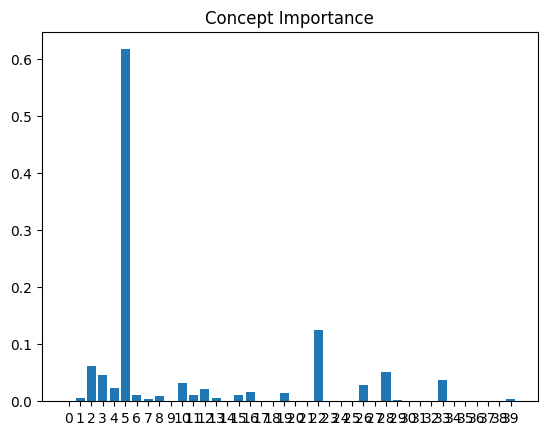

In [9]:
class_dataset = torch.Tensor([])
for X, y, y_pred in test_dataloader:
    class_dataset = torch.cat((class_dataset, X[y == class_label]))
    if len(class_dataset) >= class_dataset_size:
      class_dataset = class_dataset[:class_dataset_size]
      break


importances = craft.estimate_importance(class_dataset, class_id=class_label)
images_u = craft.transform(class_dataset)

images_u.shape

plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

most_important_concepts = np.argsort(importances)[::-1]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

In [10]:
# from math import ceil
# nb_crops = 5

# def show(img, **kwargs):
#   img = np.array(img)
#   if img.shape[0] == 3:
#     img = img.transpose(1, 2, 0)

#   img -= img.min();img /= img.max()
#   plt.imshow(img, **kwargs); plt.axis('off')

# for c_id in range(number_of_concepts):

#   best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
#   best_crops = crops[best_crops_ids]

#   print("Concept", c_id, " has an importance value of ", importances[c_id])
#   for i in range(nb_crops):
#     plt.subplot(ceil(nb_crops/5), 5, i+1)
#     show(best_crops[i])
#   plt.show()
#   print('\n\n')

## With training dataset

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


Concept 5  has an importance value of  0.5339747
Concept 22  has an importance value of  0.11826318
Concept 33  has an importance value of  0.047959007
Concept 16  has an importance value of  0.04637817
Concept 28  has an importance value of  0.031062113
Concept 2  has an importance value of  0.022400627
Concept 3  has an importance value of  0.0155489845
Concept 26  has an importance value of  0.014417559


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/craft/craft_torch.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataset[i:i+batch_size])


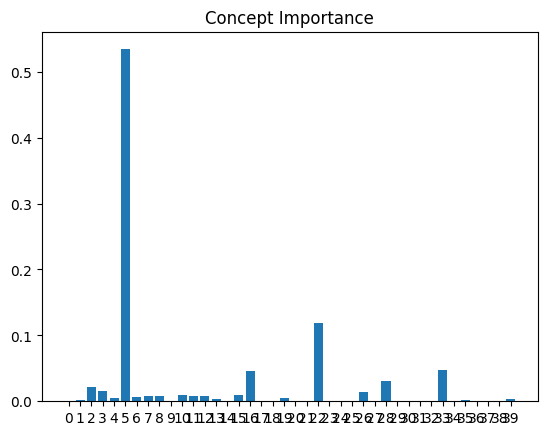

In [11]:
class_dataset = torch.Tensor([])
for X, y, y_pred in train_dataloader:
    class_dataset = torch.cat((class_dataset, X[y == class_label]))
    if len(class_dataset) >= class_dataset_size:
      class_dataset = class_dataset[:class_dataset_size]
      break


importances = craft.estimate_importance(class_dataset, class_id=class_label)
images_u = craft.transform(class_dataset)

images_u.shape

plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

most_important_concepts = np.argsort(importances)[::-1][:8]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

Concept 5  has an importance value of  0.5339747


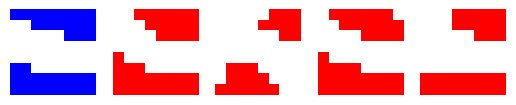




Concept 22  has an importance value of  0.11826318


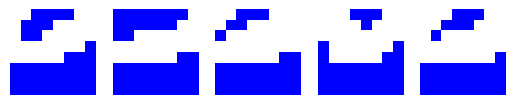




Concept 33  has an importance value of  0.047959007


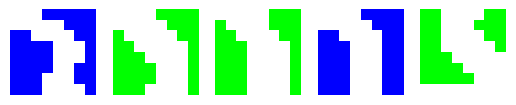




Concept 16  has an importance value of  0.04637817


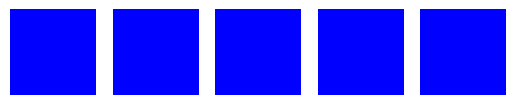




Concept 28  has an importance value of  0.031062113


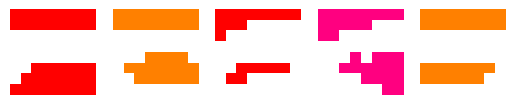




Concept 2  has an importance value of  0.022400627


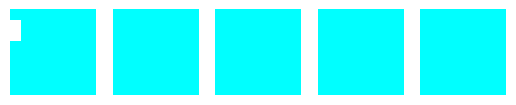




Concept 3  has an importance value of  0.0155489845


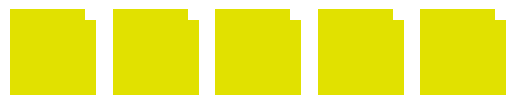




Concept 26  has an importance value of  0.014417559


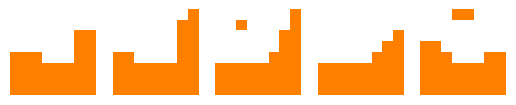

In [12]:
from math import ceil
nb_crops = 5

def show(img, **kwargs):
  img = np.array(img)
  if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

  img -= img.min();img /= img.max()
  plt.imshow(img, **kwargs); plt.axis('off')

for c_id in most_important_concepts:

  best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
  best_crops = crops[best_crops_ids]

  print("Concept", c_id, " has an importance value of ", importances[c_id])
  for i in range(nb_crops):
    plt.subplot(ceil(nb_crops/5), 5, i+1)
    show(best_crops[i])
  plt.show()
  print('\n\n')

# Recover the concept decomposition of an input

In [13]:
studied_dataloader = train_dataloader
backprop_mult = 1000

In [14]:
class Gradient_retriever():
    def __init__(self, layer):
        self.grad = None
        self.handle = layer.register_full_backward_hook(self._hook_function)
    
    def _hook_function(self, m, input_g, output_g):
        self.grad = torch.clone(input_g[0])
    
    def __del__(self):
        self.handle.remove()

gr = Gradient_retriever(list(model.children())[layer_depth-1])

In [15]:
def get_backprop_concepts(X, y, y_pred, model, concept_engine, gradient_recoverer, back_mult = 1):
    """
    Returns :
    - concept_activation : the activations for each input X
    - neg_concept_diff : the concept activation in the direction of the backpropagated gradient descent
    - pos_concept_diff : the concept activation in the direction of the backpropagated gradient ascent
    """
    activation = concept_engine.input_to_latent(X.cuda()).cpu()
    concept_activation = craft.transform(inputs=None, activations=activation)
    model.eval()
    model.zero_grad()
    outpt = model(X.to(device)).cpu()
    loss = loss_fn(outpt, y)
    loss.backward()
    back_activation = gr.grad.cpu()
    modified_activation = activation - (back_activation * back_mult)
    modified_activation[(modified_activation) < 0] = 0
    back_concept_activation = craft.transform(inputs=None, activations = modified_activation)
    neg_concept_diff = back_concept_activation +1 -1
    # neg_concept_diff = (back_concept_activation - concept_activation)
    modified_activation = activation + (back_activation * back_mult)
    modified_activation[(modified_activation) < 0] = 0
    back_concept_activation = craft.transform(inputs=None, activations = modified_activation)
    pos_concept_diff = back_concept_activation +1 -1
    # pos_concept_diff = (back_concept_activation - concept_activation)
    return concept_activation, neg_concept_diff, pos_concept_diff

In [16]:
def gather_all_concept_results(dataloader, model, concept_engine, gradient_recoverer, backprop_mult=1):
    results = {}
    output_size = 0
    for X, y, y_pred in dataloader:
        y_predi = (model(X.cuda()).cpu())
        if output_size == 0:
            output_size = len(y_predi[0])
            results = {}
        y_predi = y_predi.argmax(dim=1)
        wrongly_classified = (y_predi != y)
        X_wrong = X[wrongly_classified]
        y_wrong = y[wrongly_classified]
        y_pred_wrong = y_pred[wrongly_classified]
        y_predi_wrong = y_predi[wrongly_classified]
        concept_activation, neg_concept_diff, pos_concept_diff = get_backprop_concepts(
            X = X_wrong,
            y = y_wrong,
            y_pred = y_pred_wrong,
            model = model,
            concept_engine = concept_engine,
            gradient_recoverer = gradient_recoverer,
            back_mult = backprop_mult,
        )
        for i in range(output_size):
            if not i in results:
                results[i] = {}
            for j in range(output_size):
                if int(((y_wrong == i) & (y_predi_wrong == j)).sum()) > 0:
                    if not j in results[i]:
                        results[i][j] = (
                            concept_activation[(y_wrong == i) & (y_predi_wrong == j)],
                            neg_concept_diff[(y_wrong == i) & (y_predi_wrong == j)],
                            pos_concept_diff[(y_wrong == i) & (y_predi_wrong == j)],
                        )
                    else:
                        results[i][j] = (
                            np.concat((results[i][j][0], concept_activation[(y_wrong == i) & (y_predi_wrong == j)])),
                            np.concat((results[i][j][1], neg_concept_diff[(y_wrong == i) & (y_predi_wrong == j)])),
                            np.concat((results[i][j][2], pos_concept_diff[(y_wrong == i) & (y_predi_wrong == j)]))
                            )
    return results
results = gather_all_concept_results(studied_dataloader, model, craft, gr, backprop_mult=backprop_mult)

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


# Analyse the results

In [17]:
nb_crops = 5
nbr_concept_to_show = 8
studied_class = 9

In [18]:
def analyze_results(results, i, number_of_concept):
    # Count concepts that were added/removed when doing gradient descent
    n_appearance = np.ones(number_of_concept)
    n_added_bias = np.zeros(number_of_concept)
    n_removed_bias = np.zeros(number_of_concept)
    # Count concepts that were added/removed when doing dradient ascend
    p_appearance = np.ones(number_of_concept)
    # p_added_bias = np.zeros(number_of_concept)
    p_removed_bias = np.zeros(number_of_concept)
    for key1, val1 in results.items():
        for key2, val2 in val1.items():
            if key1 == i:
                n_appearance += len(val2[0])
                # n_appearance += ((val2[0] == 0)).sum(axis=0)
                n_added_bias += ((val2[0]==0) & (val2[1]>0)).sum(axis=0)
                n_removed_bias += ((val2[0]>0) & (val2[1]==0)).sum(axis=0)
            if key2 == i:
                p_appearance += len(val2[0])
                # p_appearance += (val2[0] > 0).sum(axis=0)
                p_removed_bias += ((val2[0]>0) & (val2[2]==0)).sum(axis=0)
    return n_added_bias, n_removed_bias, n_appearance, p_removed_bias, p_appearance

n_added_bias, n_removed_bias, n_appearance, p_removed_bias, p_appearance = analyze_results(results, studied_class, number_of_concept=number_of_concepts)

# Concepts that are often added to go in the direction of the right decision are biases
na_biases = {}
for i, val in enumerate(n_added_bias/n_appearance):
    na_biases[i]= val
# na_biases.sort(key = lambda x :x[1])

nr_biases = {}
for i, val in enumerate(n_removed_bias):
    nr_biases[i]= val
# nr_biases.sort(key = lambda x :x[1])

# Concepts that are rarely added to go in the direction of the wrong decision are biases
pr_biases = {}
for i, val in enumerate(p_removed_bias/p_appearance):
    pr_biases[i]= val
# pr_biases.sort(key = lambda x :x[1])

# print("\n\n\n\n With negative gradient addition (gradient descent)") # Biases are those that are added/removed more often
# studied_data = na_biases
# study_list = list(studied_data.items())
# study_list.sort(key=lambda x : x[1])
# for c_id, val in study_list[::-1][:nbr_concept_to_show]:
#   best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
#   best_crops = crops[best_crops_ids]

#   print("Concept", c_id, " was added ", val, " times")
#   for i in range(nb_crops):
#     plt.subplot(ceil(nb_crops/5), 5, i+1)
#     show(best_crops[i])
#   plt.show()
#   print('\n\n')



# print("\n\n\n\n With positive gradient addition") # Need to take those that are added less often
# for c_id, val in n_biases[:nbr_concept_to_show]:
#   best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
#   best_crops = crops[best_crops_ids]

#   print("Concept", c_id, " has addition/appearance ratio of ", val)
#   for i in range(nb_crops):
#     plt.subplot(ceil(nb_crops/5), 5, i+1)
#     show(best_crops[i])
#   plt.show()
#   print('\n\n')

In [19]:
# print("\n\n\n\n With negative gradient addition (gradient descent)") # Biases are those that are added/removed more often
# studied_data = get_bias_concept(results, 9, number_of_concepts)
# study_list = list(studied_data.items())
# study_list.sort(key=lambda x : x[1])
# for c_id, val in study_list[::-1][:nbr_concept_to_show]:
#   best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
#   best_crops = crops[best_crops_ids]

#   print("Concept", c_id, " was added ", val, " times")
#   for i in range(nb_crops):
#     plt.subplot(ceil(nb_crops/5), 5, i+1)
#     show(best_crops[i])
#   plt.show()
#   print('\n\n')

The identified bias is the concept number 19 which got a score of 2.9502004166350413 .


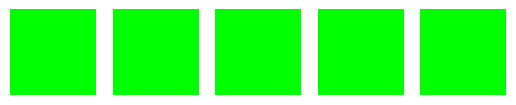




The identified bias is the concept number 10 which got a score of 1.3439784741387149 .


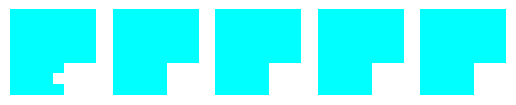




The identified bias is the concept number 16 which got a score of 1.0429628075978319 .


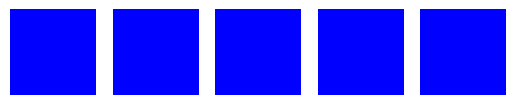

In [20]:
def get_bias_concept(results, studied_class, number_of_concepts):
    n_added_bias, n_removed_bias, n_appearance, p_removed_bias, p_appearance = analyze_results(results, studied_class, number_of_concept=number_of_concepts)
    na_biases = {}
    for i, val in enumerate(n_added_bias/n_appearance):
        na_biases[i]= val
    nr_biases = {}
    for i, val in enumerate(n_removed_bias):
        nr_biases[i]= val
    pr_biases = {}
    for i, val in enumerate(p_removed_bias/p_appearance):
        pr_biases[i]= val
    ultimate_bias = {}
    for key, val in na_biases.items():
        ultimate_bias[key]= val - pr_biases[key]
    return ultimate_bias


most_biased_concepts = []
concept_to_show = 1
res = {}
for classes in range(10):
        biases = get_bias_concept(results=results, studied_class=classes, number_of_concepts=number_of_concepts)
        study_list = list(biases.items())
        study_list.sort(key=lambda x : x[1])
        for c_id, val in study_list[::-1][:]:
            if c_id in res:
                res[c_id] = res[c_id] + val
            else :
                res[c_id] = val
res = [(key, val) for key, val in res.items()]
res.sort(key= lambda x: -x[1])
for c_id, val in res[:3]:
    best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
    best_crops = crops[best_crops_ids]
    print("The identified bias is the concept number", c_id, "which got a score of", val, ".")
    if not c_id in most_biased_concepts and val > 0.16:
        most_biased_concepts.append(c_id)
    for i in range(nb_crops):
        plt.subplot(ceil(nb_crops/5), 5, i+1)
        show(best_crops[i])
    plt.show()
    print('\n\n')

The identified bias is the concept number 10 which got a score of 0.8409096086382069 .


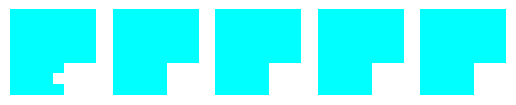




The identified bias is the concept number 19 which got a score of 0.8321304063623489 .


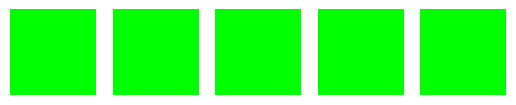




The identified bias is the concept number 23 which got a score of 0.6631713694302211 .


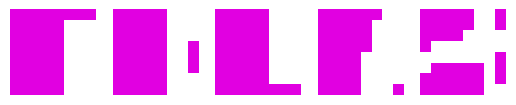




The identified bias is the concept number 12 which got a score of 0.628372571122542 .


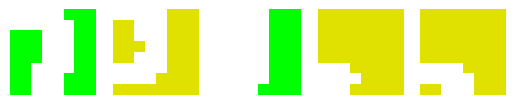




The identified bias is the concept number 17 which got a score of 0.6087891247892843 .


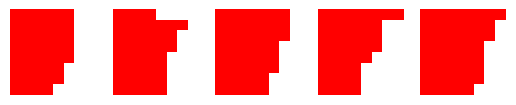

In [21]:
def get_bias_concept(results, studied_class, number_of_concepts):
    n_added_bias, n_removed_bias, n_appearance, p_removed_bias, p_appearance = analyze_results(results, studied_class, number_of_concept=number_of_concepts)
    na_biases = {}
    for i, val in enumerate(n_added_bias/n_appearance):
        na_biases[i]= val
    nr_biases = {}
    for i, val in enumerate(n_removed_bias):
        nr_biases[i]= val
    pr_biases = {}
    for i, val in enumerate(p_removed_bias/p_appearance):
        pr_biases[i]= val
    ultimate_bias = {}
    for key, val in na_biases.items():
        ultimate_bias[key]= val - pr_biases[key]
    return ultimate_bias


most_biased_concepts = []
concept_to_show = 1
res = {}
for classes in range(10):
        biases = get_bias_concept(results=results, studied_class=classes, number_of_concepts=number_of_concepts)
        study_list = list(biases.items())
        study_list.sort(key=lambda x : x[1])
        for c_id, val in study_list[::-1][:]:
            if c_id in res:
                res[c_id] = max(res[c_id], val)
            else :
                res[c_id] = val
res = [(key, val) for key, val in res.items()]
res.sort(key= lambda x: -x[1])
for c_id, val in res[:5]:
    best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
    best_crops = crops[best_crops_ids]
    print("The identified bias is the concept number", c_id, "which got a score of", val, ".")
    if not c_id in most_biased_concepts and val > 0.16:
        most_biased_concepts.append(c_id)
    for i in range(nb_crops):
        plt.subplot(ceil(nb_crops/5), 5, i+1)
        show(best_crops[i])
    plt.show()
    print('\n\n')

In [22]:
# studied_class = 5
# biases = get_bias_concept(results=results, studied_class=studied_class, number_of_concepts=number_of_concepts)
# study_list = list(biases.items())
# study_list.sort(key=lambda x : x[1])
# for c_id, val in study_list[::-1][:6]:
#     best_crops_ids = np.argsort(crops_u[:, c_id])[::-1][:nb_crops]
#     best_crops = crops[best_crops_ids]

#     print("For class '", studied_class, ", the identified bias is the concept number", c_id, "which got a score of", val, ".")
#     for i in range(nb_crops):
#         plt.subplot(ceil(nb_crops/5), 5, i+1)
#         show(best_crops[i])
#     plt.show()
# print('\n\n')

In [23]:
concept_path = f"models/concepts_{exp_name}_model_{exp_id}_{epochs}_{train_correlation}_{number_of_concepts}"
with open(concept_path, "wb") as f:
    pkl.dump((crops, crops_u, w, craft.reducer, most_biased_concepts), f)

most_biased_concepts

[10, 19, 23, 12, 17]

In [24]:
len(train_dataloader)*batch_size/10 /100/10

6.016